# 📊 Interactive Sales Dashboard
A 7-day guided build: Seaborn statistics -> heatmaps -> a coordinated 2x2 dashboard -> a fully interactive Plotly dashboard.

**Dataset:** `sales_data.csv` — 100 orders, 5 products (Phone, Headphones, Laptop, Tablet, Monitor), 4 regions (East, North, West, South), Jan–Apr 2024.


## Day 1 — Seaborn Basics
Load the data, set a cohesive color theme, and build our first plots: a sales trend line and a revenue-by-product bar chart.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cohesive brand palette used across every chart in this notebook
PALETTE = {
    "navy": "#1B2A4A", "teal": "#2E9E9E", "coral": "#F26B5B",
    "gold": "#F2B33D", "slate": "#6C7A89",
}
PALETTE_LIST = list(PALETTE.values())
sns.set_theme(style="whitegrid", palette=PALETTE_LIST)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14

df = pd.read_csv("sales_data.csv", parse_dates=["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Spend_Tier"] = pd.qcut(df["Total_Sales"], q=3, labels=["Low Value", "Mid Value", "High Value"])

products = sorted(df["Product"].unique())
PRODUCT_COLORS = {p: PALETTE_LIST[i % len(PALETTE_LIST)] for i, p in enumerate(products)}

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month,Spend_Tier
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024-01,High Value
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024-01,Mid Value
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024-01,Low Value
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024-01,Low Value
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024-01,High Value


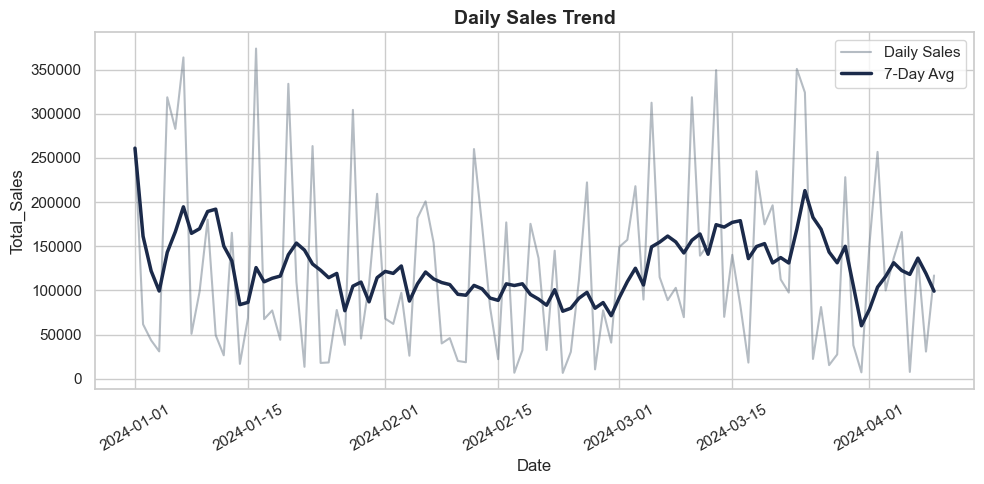

In [4]:
# Basic plot #1: daily sales trend with a 7-day rolling average
daily = df.groupby("Date", as_index=False)["Total_Sales"].sum()
daily["Rolling_7d"] = daily["Total_Sales"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=daily, x="Date", y="Total_Sales", color=PALETTE["slate"], alpha=0.5, label="Daily Sales", ax=ax)
sns.lineplot(data=daily, x="Date", y="Rolling_7d", color=PALETTE["navy"], linewidth=2.5, label="7-Day Avg", ax=ax)
ax.set_title("Daily Sales Trend")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

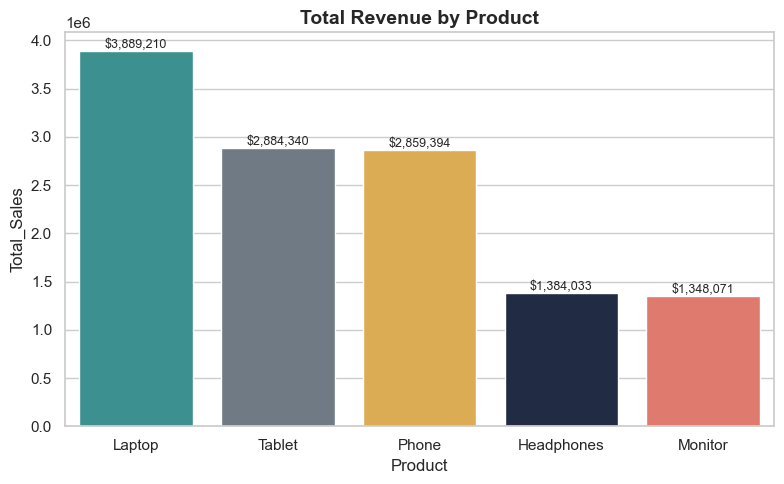

In [5]:
# Basic plot #2: total revenue by product (customized colors + value labels)
totals = df.groupby("Product", as_index=False)["Total_Sales"].sum().sort_values("Total_Sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=totals, x="Product", y="Total_Sales", hue="Product", palette=PRODUCT_COLORS, legend=False, ax=ax)
for i, v in enumerate(totals["Total_Sales"]):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Total Revenue by Product")
plt.tight_layout()
plt.show()

## Day 2 — Statistical Visualizations
Box plots and violin plots to see distributions, plus a scatter view of customer segments, with statistical annotations (medians).

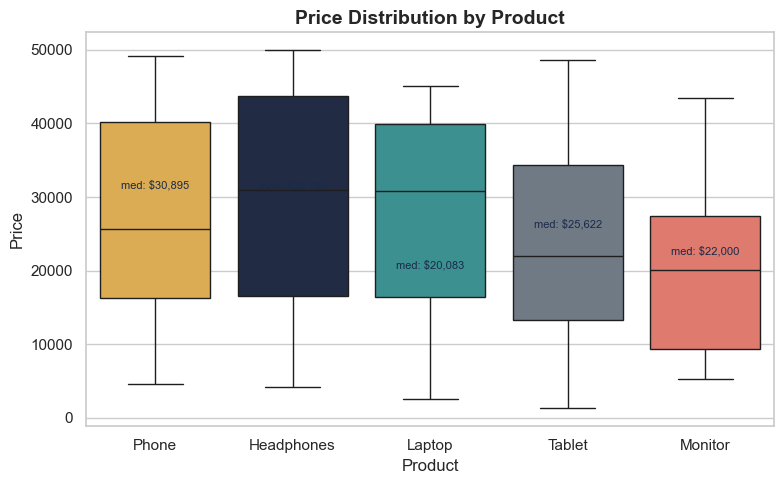

In [6]:
# Box plot: price distribution by product, annotated with medians
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Product", y="Price", hue="Product", palette=PRODUCT_COLORS, legend=False, ax=ax)
medians = df.groupby("Product")["Price"].median()
for i, p in enumerate(products):
    ax.text(i, medians[p], f"med: ${medians[p]:,.0f}", ha="center", va="bottom", fontsize=8, color=PALETTE["navy"])
ax.set_title("Price Distribution by Product")
plt.tight_layout()
plt.show()

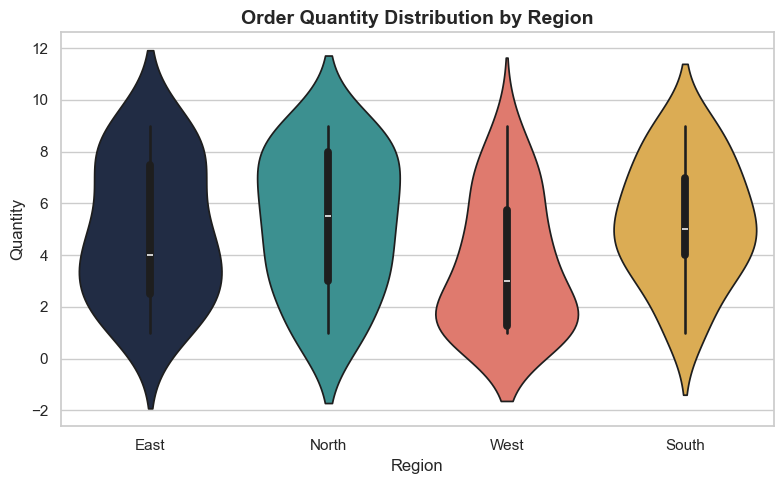

In [7]:
# Violin plot: order quantity distribution by region
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="Region", y="Quantity", hue="Region", palette=PALETTE_LIST[:df['Region'].nunique()], legend=False, ax=ax)
ax.set_title("Order Quantity Distribution by Region")
plt.tight_layout()
plt.show()

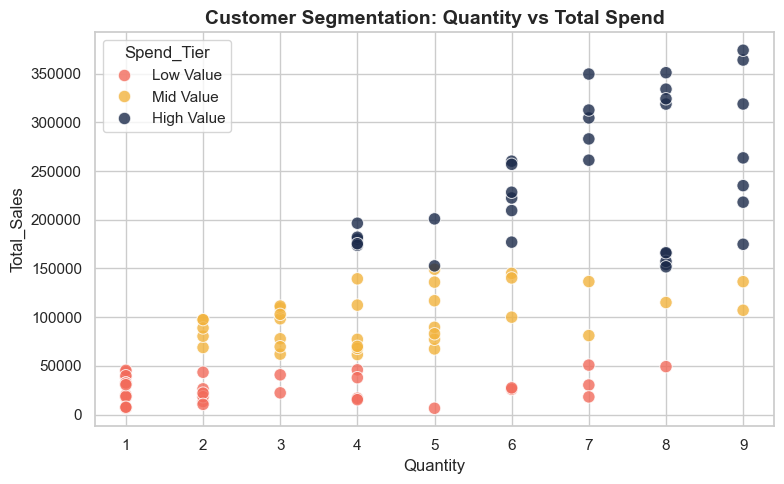

In [8]:
# Customer segmentation scatter: spend tier by quantity vs total sales
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Quantity", y="Total_Sales", hue="Spend_Tier",
                 palette=[PALETTE["coral"], PALETTE["gold"], PALETTE["navy"]], s=80, alpha=0.8, ax=ax)
ax.set_title("Customer Segmentation: Quantity vs Total Spend")
plt.tight_layout()
plt.show()

## Day 3 — Heatmaps & Correlation
A numeric correlation matrix, plus a custom Region × Product revenue heatmap.

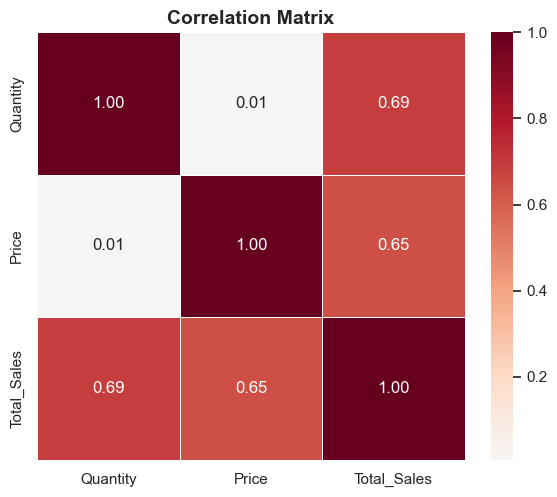

In [9]:
# Correlation matrix
corr = df[["Quantity", "Price", "Total_Sales"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

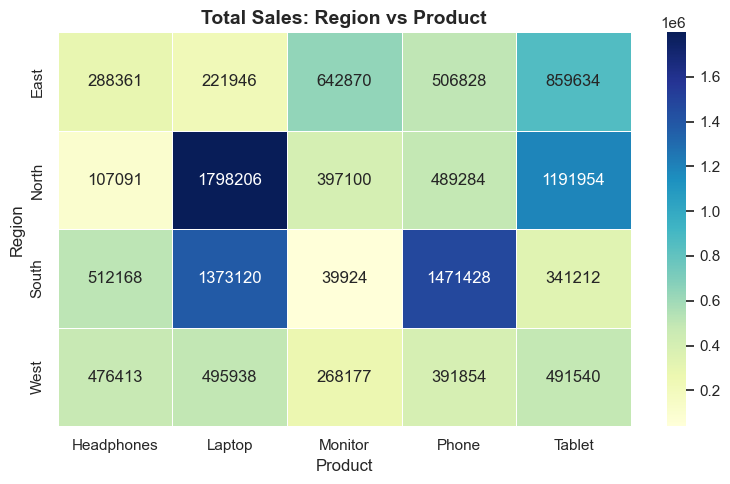

In [10]:
# Custom heatmap: total sales by Region x Product
pivot = df.pivot_table(values="Total_Sales", index="Region", columns="Product", aggfunc="sum", fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Total Sales: Region vs Product")
plt.tight_layout()
plt.show()

## Day 4 — Multi-plot Dashboard (2x2 Grid)
Combine four of the views above into one coordinated, consistently-themed dashboard figure.

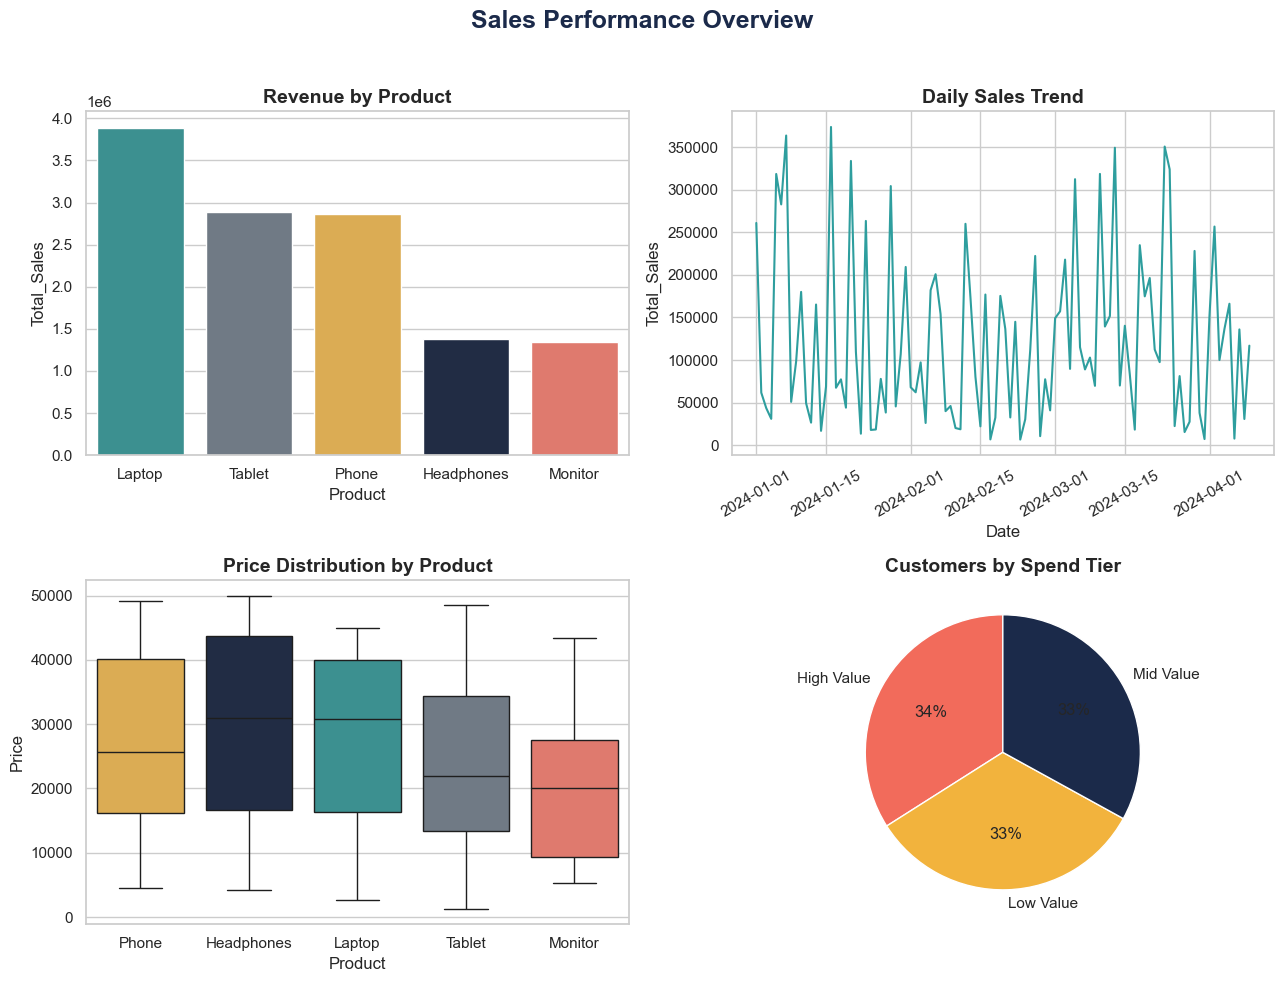

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Sales Performance Overview", fontsize=18, fontweight="bold", color=PALETTE["navy"])

sns.barplot(data=totals, x="Product", y="Total_Sales", hue="Product", palette=PRODUCT_COLORS, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Revenue by Product")

sns.lineplot(data=daily, x="Date", y="Total_Sales", color=PALETTE["teal"], ax=axes[0, 1])
axes[0, 1].set_title("Daily Sales Trend")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="Product", y="Price", hue="Product", palette=PRODUCT_COLORS, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Price Distribution by Product")

tier_counts = df["Spend_Tier"].value_counts()
axes[1, 1].pie(tier_counts.values, labels=tier_counts.index, autopct="%1.0f%%",
               colors=[PALETTE["coral"], PALETTE["gold"], PALETTE["navy"]], startangle=90,
               wedgeprops={"edgecolor": "white"})
axes[1, 1].set_title("Customers by Spend Tier")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Day 5 — Interactive Visualizations (Plotly)
Add hover tooltips and an animation: cumulative revenue by product, month over month.

In [12]:
import plotly.express as px

monthly = df.groupby(["Month", "Product"], as_index=False)["Total_Sales"].sum().sort_values("Month")
monthly["Cumulative"] = monthly.groupby("Product")["Total_Sales"].cumsum()

fig = px.bar(monthly, x="Product", y="Cumulative", color="Product", color_discrete_map=PRODUCT_COLORS,
             animation_frame="Month", range_y=[0, monthly["Cumulative"].max() * 1.1],
             title="Cumulative Revenue by Product Over Time", template="plotly_white")
fig.update_layout(showlegend=False, height=500)
fig.show()

## Day 6 — Dashboard Integration
Combine everything into one interactive Plotly dashboard with a Region dropdown filter. This mirrors what `dashboard.py` builds and saves as `dashboard.html`.

In [13]:
import dashboard as dash_module

# Re-use the same data-prep + chart-building functions from dashboard.py
df2 = dash_module.load_data("sales_data.csv")
fig = dash_module.build_interactive_dashboard(df2, out_html="dashboard.html")
fig.show()

Interactive dashboard saved to dashboard.html


## Day 7 — Polish & Presentation
All static charts are saved under `visualizations/`, the full interactive dashboard is `dashboard.html`, and `dashboard_demo.gif` cycles through the key views for a quick preview (e.g. in a README or slide deck).

**Key takeaways:**
- Laptops and Phones drive the highest revenue; Headphones has the lowest average price with the tightest spread.
- Quantity and Total_Sales are strongly correlated (as expected), while Price contributes independently — see the correlation heatmap.
- The `High Value` spend tier customers cluster at both higher quantities and higher unit prices.
- Use the Region dropdown in `dashboard.html` to compare regional performance interactively.